Saving heart_disease_health_indicators_BRFSS2015.csv.zip to heart_disease_health_indicators_BRFSS2015.csv (1).zip
Files: ['heart_disease_health_indicators_BRFSS2015.csv']
Dataset Shape: (253680, 22)
   HeartDiseaseorAttack  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                   0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1                   0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2                   0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3                   0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4                   0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   Diabetes  PhysActivity  Fruits  ...  AnyHealthcare  NoDocbcCost  GenHlth  \
0       0.0           0.0     0.0  ...            1.0          0.0      5.0   
1       0.0           1.0     0.0  ...            0.0          1.0      3.0   
2       0.0           0.0     1.0  ...            1.0          1.0      5.0   
3       0.0     

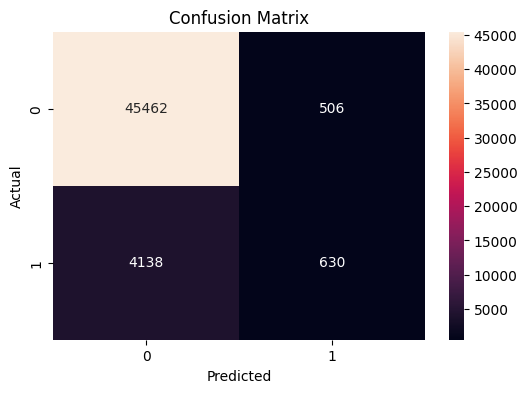

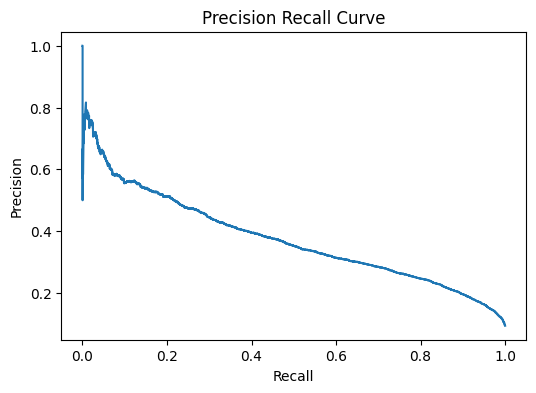

In [ ]:

# (1) LOGISTIC REGRESSION

import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve


uploaded = files.upload()

zip_name = list(uploaded.keys())[0]


with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Files:", os.listdir("data"))


csv_file = [f for f in os.listdir("data") if f.endswith(".csv")][0]

data = pd.read_csv("data/" + csv_file)

print("Dataset Shape:", data.shape)
print(data.head())


y = data["HeartDiseaseorAttack"]

X = data.drop("HeartDiseaseorAttack", axis=1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


print("\n=== Logistic Regression Results ===")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)

plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

Saving heart_disease_health_indicators_BRFSS2015.csv.zip to heart_disease_health_indicators_BRFSS2015.csv (2).zip
Files: ['heart_disease_health_indicators_BRFSS2015.csv']
Dataset Shape: (253680, 22)
   HeartDiseaseorAttack  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                   0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1                   0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2                   0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3                   0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4                   0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   Diabetes  PhysActivity  Fruits  ...  AnyHealthcare  NoDocbcCost  GenHlth  \
0       0.0           0.0     0.0  ...            1.0          0.0      5.0   
1       0.0           1.0     0.0  ...            0.0          1.0      3.0   
2       0.0           0.0     1.0  ...            1.0          1.0      5.0   
3       0.0     

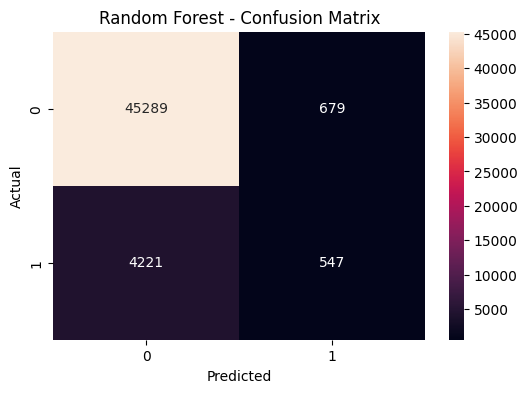

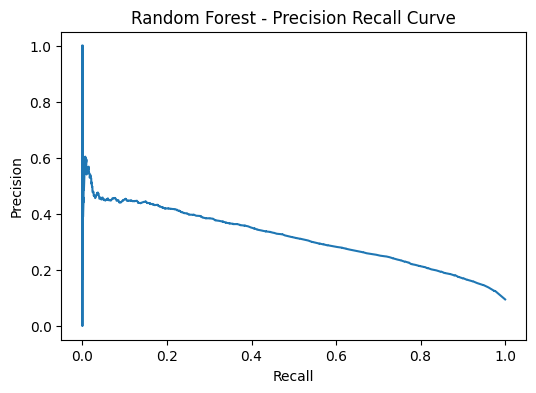

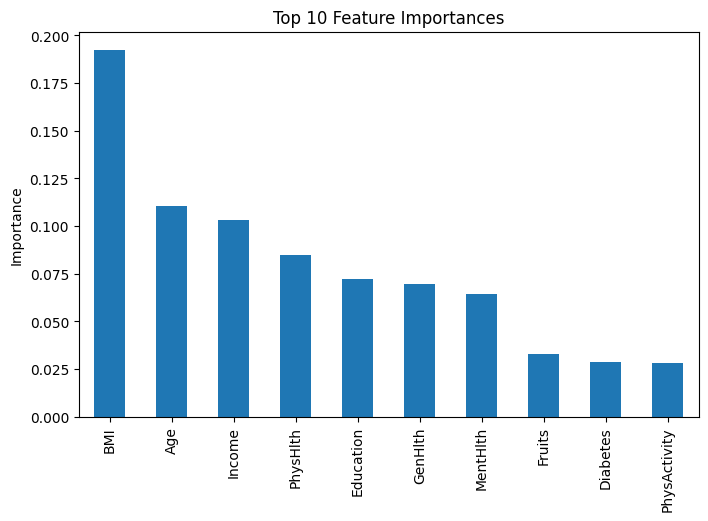

In [ ]:

#- (2) RANDOM FOREST



import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve

uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Files:", os.listdir("data"))


csv_file = [f for f in os.listdir("data") if f.endswith(".csv")][0]

data = pd.read_csv("data/" + csv_file)

print("Dataset Shape:", data.shape)
print(data.head())


y = data["HeartDiseaseorAttack"]
X = data.drop("HeartDiseaseorAttack", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("\n=== Random Forest Results ===")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)

plt.title("Random Forest - Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
importance.plot(kind="bar")

plt.title("Top 10 Feature Importances")
plt.ylabel("Importance")
plt.show()

Saving heart_disease_health_indicators_BRFSS2015.csv.zip to heart_disease_health_indicators_BRFSS2015.csv (3).zip
=== KNN Results ===
Accuracy : 0.8964837590665405
Precision: 0.3794820717131474
Recall   : 0.15981543624161074
F1 Score : 0.22491145218417946


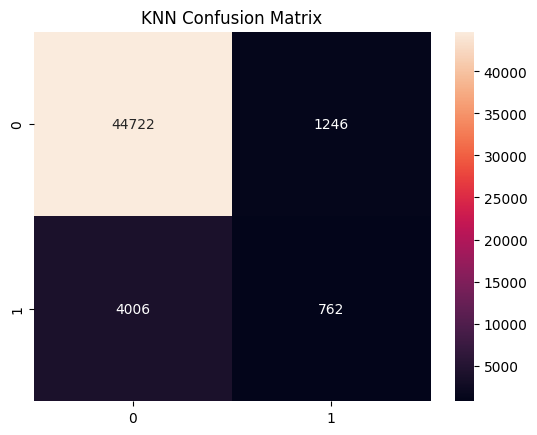

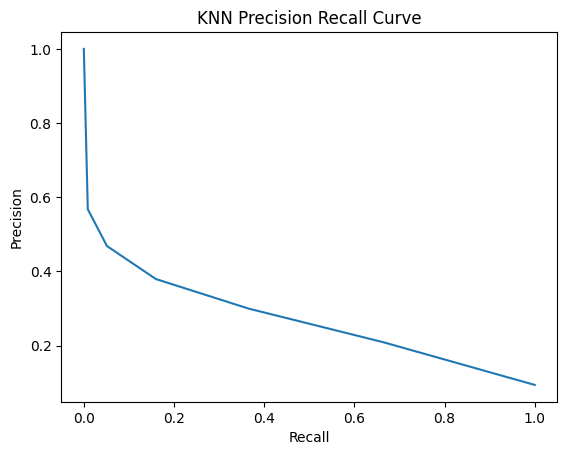

In [ ]:

#   (3) HEART DISEASE PREDICTION - KNN


import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve


uploaded = files.upload()
zip_name = list(uploaded.keys())[0]


with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("data")


csv_file = [f for f in os.listdir("data") if f.endswith(".csv")][0]
data = pd.read_csv("data/" + csv_file)


y = data["HeartDiseaseorAttack"]
X = data.drop("HeartDiseaseorAttack", axis=1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


print("=== KNN Results ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("KNN Confusion Matrix")
plt.show()


precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision)
plt.title("KNN Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

Saving heart_disease_health_indicators_BRFSS2015.csv.zip to heart_disease_health_indicators_BRFSS2015.csv (12).zip
=== Naive Bayes Results ===
Accuracy : 0.8193196152633239
Precision: 0.2718124286751738
Recall   : 0.549496644295302
F1 Score : 0.363712084403415


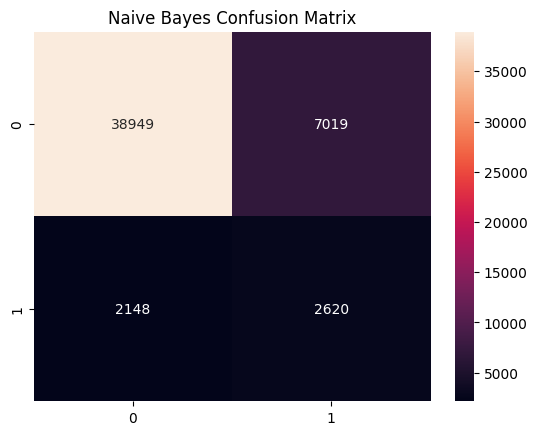

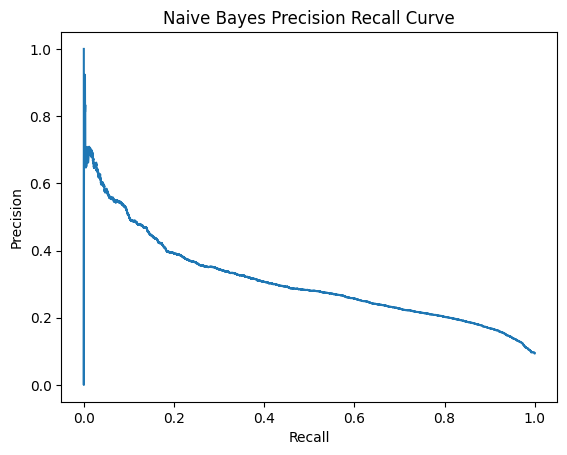

In [ ]:

#  (4)- NAIVE BAYES


import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve

uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("data")


csv_file = [f for f in os.listdir("data") if f.endswith(".csv")][0]
data = pd.read_csv("data/" + csv_file)

y = data["HeartDiseaseorAttack"]
X = data.drop("HeartDiseaseorAttack", axis=1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = GaussianNB()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


print("=== Naive Bayes Results ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Naive Bayes Confusion Matrix")
plt.show()


precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision)
plt.title("Naive Bayes Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00


Saving heart_disease_health_indicators_BRFSS2015.csv.zip to heart_disease_health_indicators_BRFSS2015.csv (5).zip
Files: ['heart_disease_health_indicators_BRFSS2015.csv']
Dataset Shape: (253680, 22)
   HeartDiseaseorAttack  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                   0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1                   0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2                   0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3                   0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4                   0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   Diabetes  PhysActivity  Fruits  ...  AnyHealthcare  NoDocbcCost  GenHlth  \
0       0.0           0.0     0.0  ...            1.0          0.0      5.0   
1       0.0           1.0     0.0  ...            0.0          1.0      3.0   
2       0.0           0.0     1.0  ...            1.0          1.0      5.0   
3       0.0     

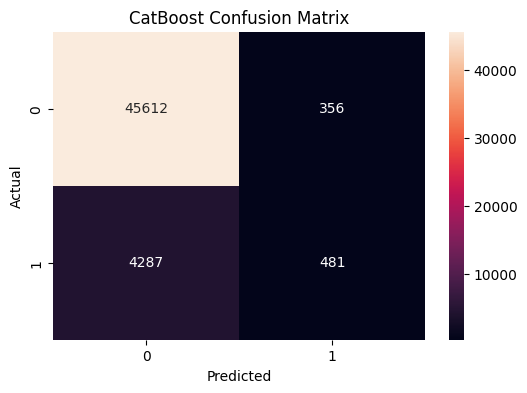

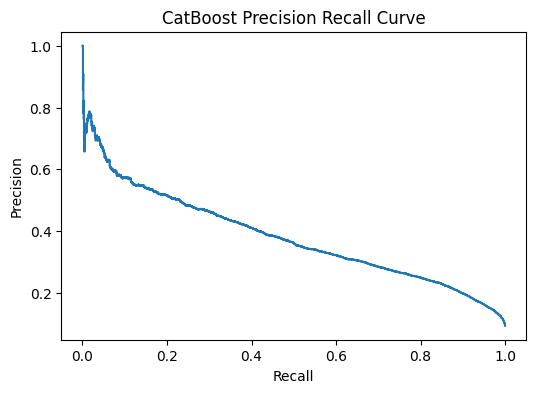

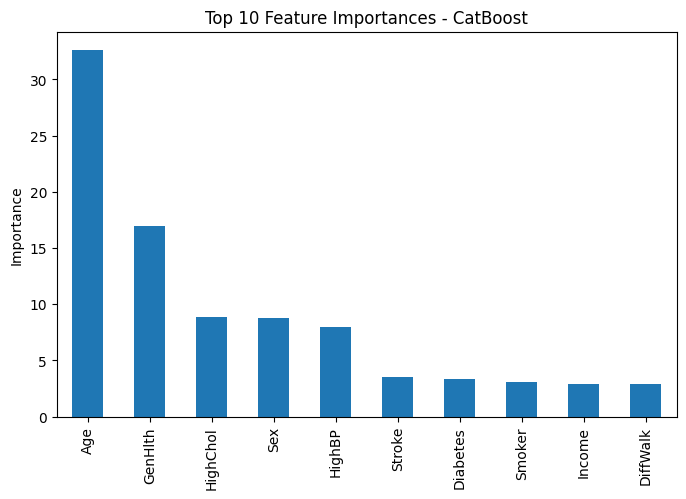

In [ ]:

# (5)- CATBOOST


import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score


!pip install -q catboost

from catboost import CatBoostClassifier


uploaded = files.upload()
zip_name = list(uploaded.keys())[0]


with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Files:", os.listdir("data"))


csv_file = [f for f in os.listdir("data") if f.endswith(".csv")][0]

data = pd.read_csv("data/" + csv_file)

print("Dataset Shape:", data.shape)
print(data.head())


y = data["HeartDiseaseorAttack"]
X = data.drop("HeartDiseaseorAttack", axis=1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='Accuracy',
    verbose=0,
    random_state=42
)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_pred = y_pred.astype(int)

y_prob = model.predict_proba(X_test)[:,1]


print("\n=== CatBoost Results ===")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("CatBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.title("CatBoost Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc_score(y_test, y_prob))
plt.plot([0,1], [0,1], linestyle="--")
plt.title("CatBoost ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
importance.plot(kind="bar")

plt.title("Top 10 Feature Importances - CatBoost")
plt.ylabel("Importance")
plt.show()

Saving heart_disease_health_indicators_BRFSS2015.csv.zip to heart_disease_health_indicators_BRFSS2015.csv (6).zip
Files: ['heart_disease_health_indicators_BRFSS2015.csv']
Dataset Shape: (253680, 22)
   HeartDiseaseorAttack  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                   0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1                   0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2                   0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3                   0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4                   0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   Diabetes  PhysActivity  Fruits  ...  AnyHealthcare  NoDocbcCost  GenHlth  \
0       0.0           0.0     0.0  ...            1.0          0.0      5.0   
1       0.0           1.0     0.0  ...            0.0          1.0      3.0   
2       0.0           0.0     1.0  ...            1.0          1.0      5.0   
3       0.0     

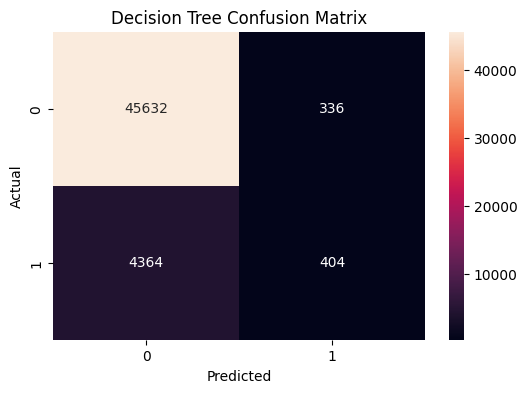

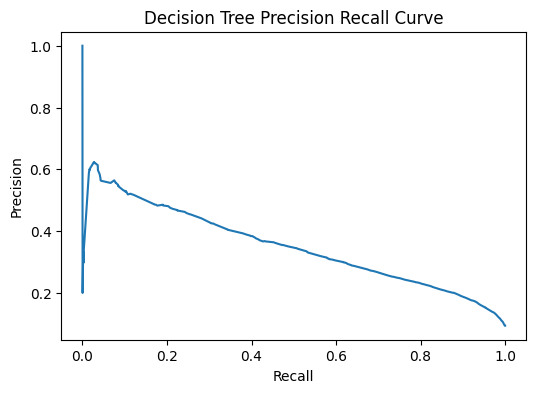

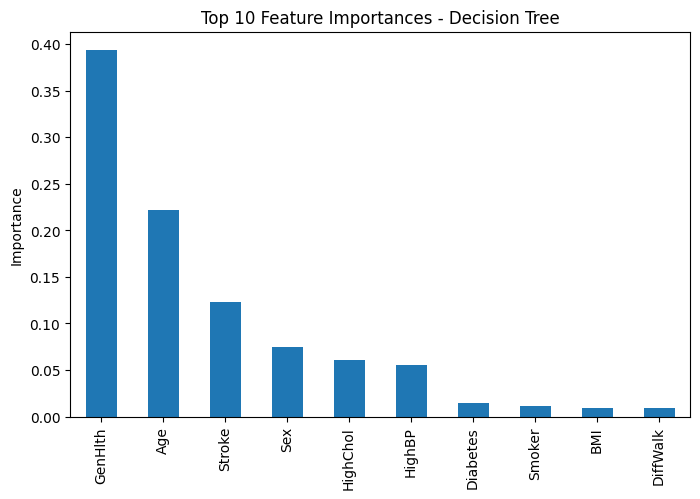

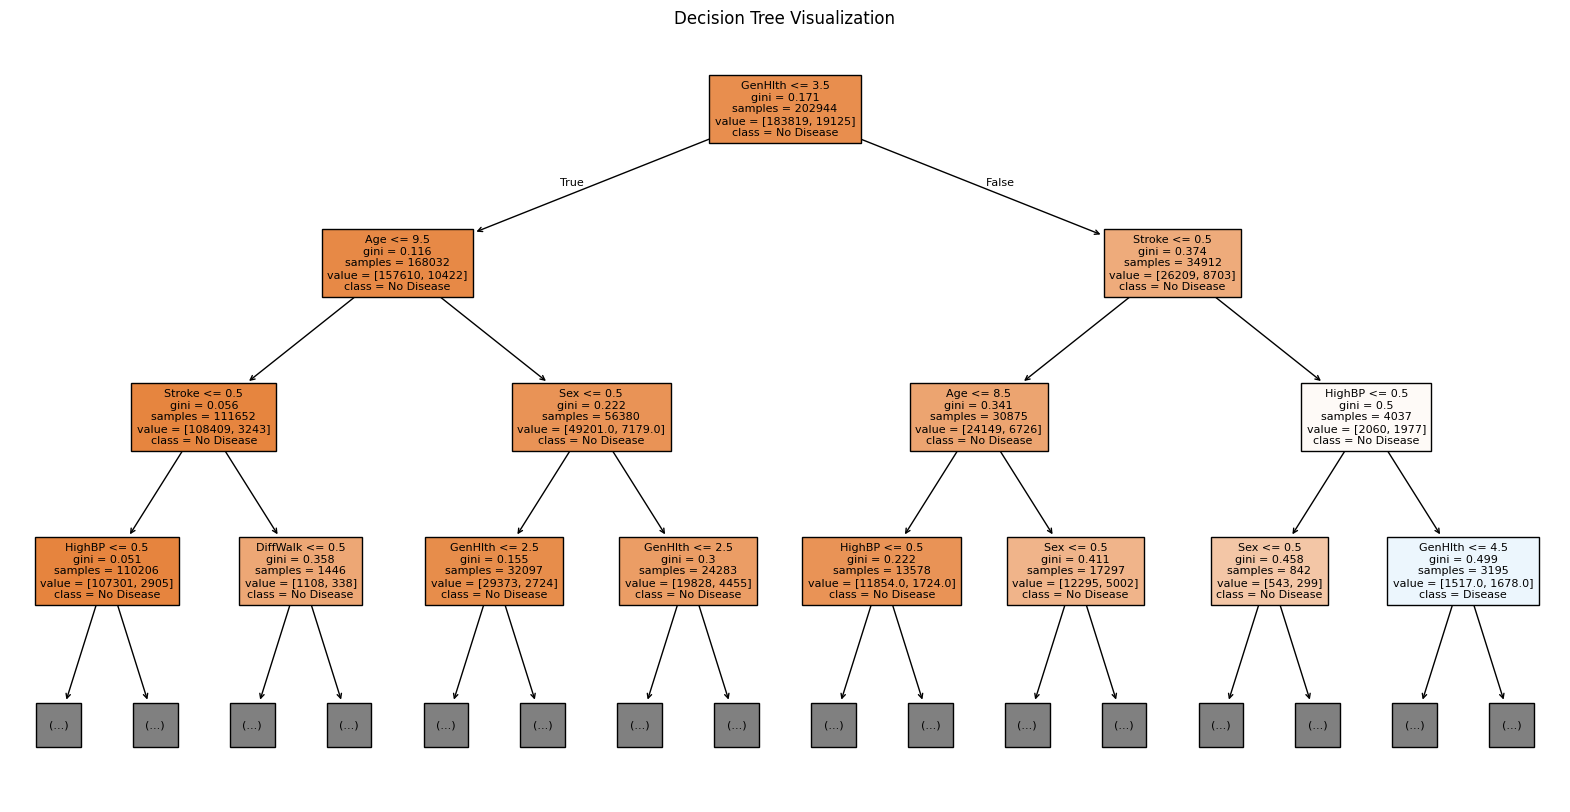

In [ ]:

# (6)- DECISION TREE


import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve


uploaded = files.upload()

zip_name = list(uploaded.keys())[0]


with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Files:", os.listdir("data"))


csv_file = [f for f in os.listdir("data") if f.endswith(".csv")][0]

data = pd.read_csv("data/" + csv_file)

print("Dataset Shape:", data.shape)
print(data.head())


y = data["HeartDiseaseorAttack"]
X = data.drop("HeartDiseaseorAttack", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=8,
    min_samples_split=10,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


print("\n=== Decision Tree Results ===")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

----
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)

plt.title("Decision Tree Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
importance.plot(kind="bar")

plt.title("Top 10 Feature Importances - Decision Tree")
plt.ylabel("Importance")
plt.show()


plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.show()

Saving heart_disease_health_indicators_BRFSS2015.csv.zip to heart_disease_health_indicators_BRFSS2015.csv (7).zip
Files: ['heart_disease_health_indicators_BRFSS2015.csv']
Dataset Shape: (253680, 22)
   HeartDiseaseorAttack  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                   0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1                   0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2                   0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3                   0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4                   0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   Diabetes  PhysActivity  Fruits  ...  AnyHealthcare  NoDocbcCost  GenHlth  \
0       0.0           0.0     0.0  ...            1.0          0.0      5.0   
1       0.0           1.0     0.0  ...            0.0          1.0      3.0   
2       0.0           0.0     1.0  ...            1.0          1.0      5.0   
3       0.0     

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:33:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost Results ===
Accuracy : 0.9078169347209082
Precision: 0.5486631016042781
Recall   : 0.10759228187919463
F1 Score : 0.17990531299316148


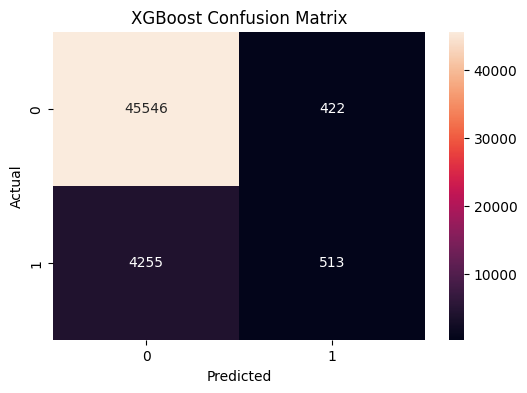

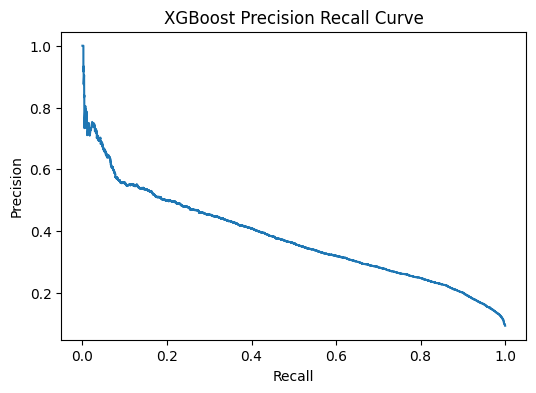

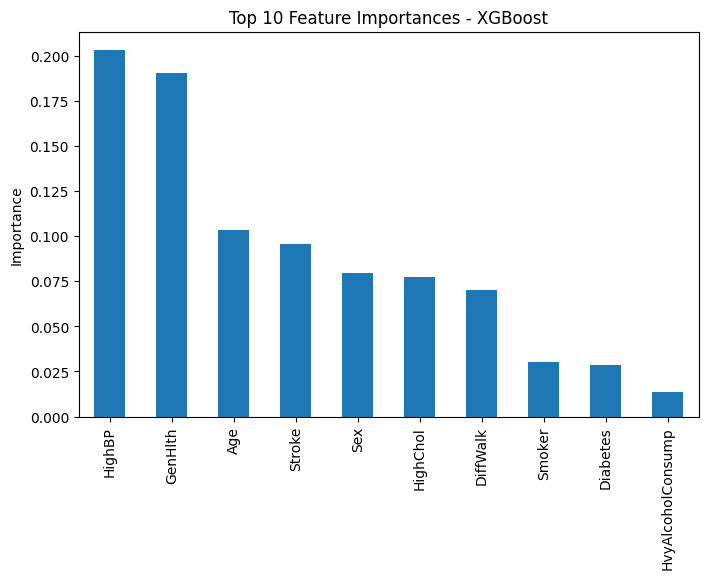

In [ ]:

# (7) - XGBOOST


import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve

!pip install -q xgboost

from xgboost import XGBClassifier

uploaded = files.upload()

zip_name = list(uploaded.keys())[0]


with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Files:", os.listdir("data"))


csv_file = [f for f in os.listdir("data") if f.endswith(".csv")][0]

data = pd.read_csv("data/" + csv_file)

print("Dataset Shape:", data.shape)
print(data.head())


y = data["HeartDiseaseorAttack"]
X = data.drop("HeartDiseaseorAttack", axis=1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


print("\n=== XGBoost Results ===")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)

plt.title("XGBoost Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
importance.plot(kind="bar")

plt.title("Top 10 Feature Importances - XGBoost")
plt.ylabel("Importance")
plt.show()

Saving heart_disease_health_indicators_BRFSS2015.csv.zip to heart_disease_health_indicators_BRFSS2015.csv (11).zip
Dataset Shape: (253680, 22)
Best Threshold: 0.3

=== FINAL RESULTS ===
Accuracy : 0.8764585304320404
Precision: 0.3716157958268667
Recall   : 0.4509311571458464
F1 Score : 0.40744942333144263
ROC AUC  : 0.8464442750402028


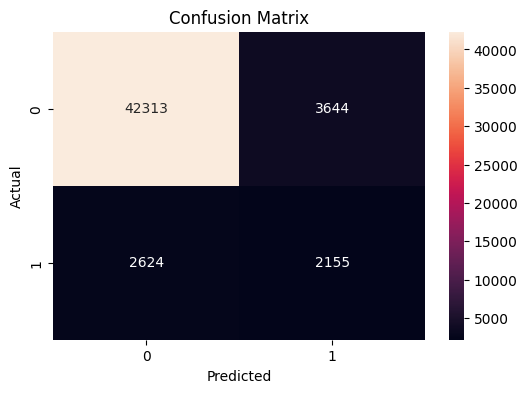

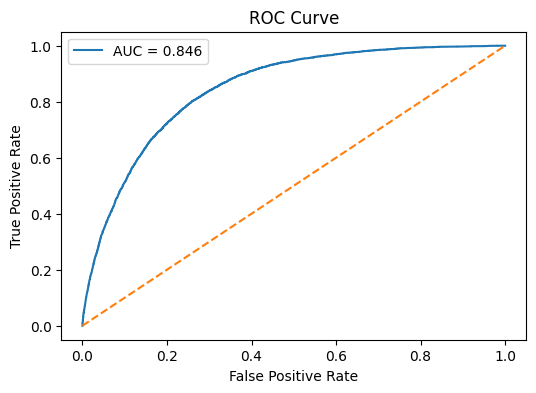

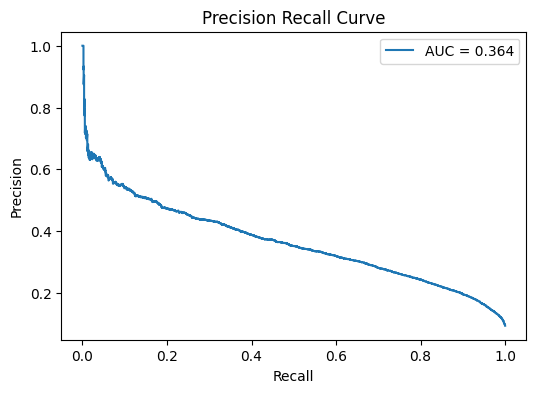

In [ ]:

# PROPOSED MODEL:
# SMOTE + CATBOOST + XGBOOST + AUTO THRESHOLD OPTIMIZATION
# WITH PR CURVE + ROC CURVE


import zipfile
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files


!pip install -q xgboost catboost imbalanced-learn

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc

from sklearn.ensemble import VotingClassifier
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("data")

csv_file = [f for f in os.listdir("data") if f.endswith(".csv")][0]
data = pd.read_csv("data/" + csv_file)

print("Dataset Shape:", data.shape)

y = data["HeartDiseaseorAttack"]
X = data.drop("HeartDiseaseorAttack", axis=1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#  SMOTE

smote = SMOTE(sampling_strategy=0.7, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


cat_model = CatBoostClassifier(
    iterations=250,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model = VotingClassifier(
    estimators=[
        ("cat", cat_model),
        ("xgb", xgb_model)
    ],
    voting="soft"
)

model.fit(X_train_sm, y_train_sm)

y_prob = model.predict_proba(X_test)[:,1]


#  Auto Threshold Search

best_score = 0
best_threshold = 0.50

for t in np.arange(0.30, 0.71, 0.02):

    preds = (y_prob >= t).astype(int)

    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds)

    score = (0.6 * f1) + (0.4 * acc)

    if score > best_score:
        best_score = score
        best_threshold = t

print("Best Threshold:", best_threshold)


y_pred = (y_prob >= best_threshold).astype(int)


print("\n=== FINAL RESULTS ===")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, label="AUC = %.3f" % pr_auc)
plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


=== MODEL COMPARISON (WITHOUT HYBRID) ===
                    Model  Accuracy  Precision  Recall  F1 Score  \
Rank                                                               
1                 XGBoost      0.89       0.55    0.36      0.43   
2                CatBoost      0.89       0.58    0.33      0.42   
3             Naive Bayes      0.84       0.29    0.48      0.36   
4           Decision Tree      0.83       0.31    0.39      0.35   
5           Random Forest      0.89       0.52    0.22      0.31   
6                     KNN      0.86       0.34    0.27      0.30   
7     Logistic Regression      0.88       0.41    0.18      0.25   

      Overall Score  
Rank                 
1             0.574  
2             0.562  
3             0.558  
4             0.528  
5             0.490  
6             0.488  
7             0.453  


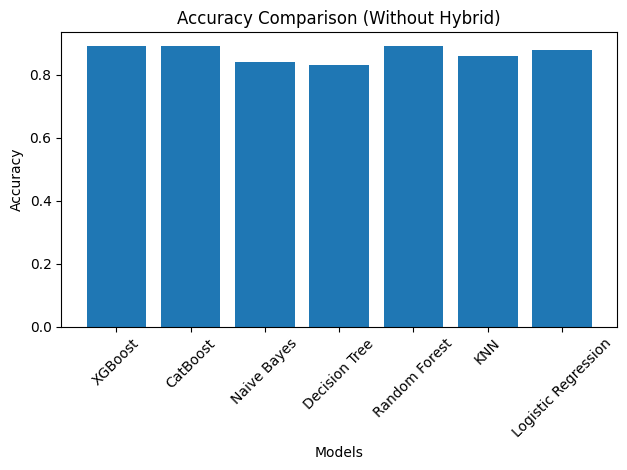

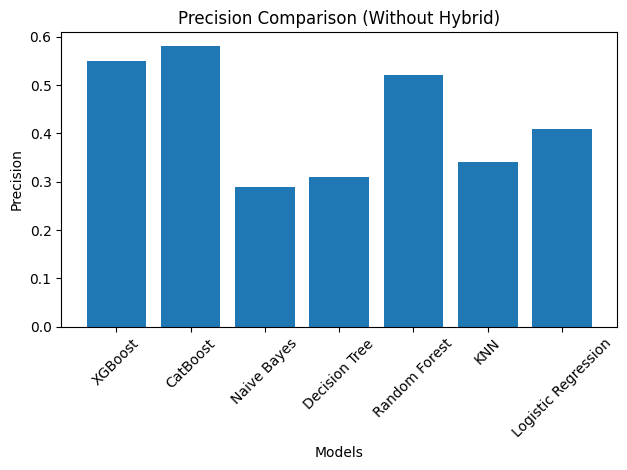

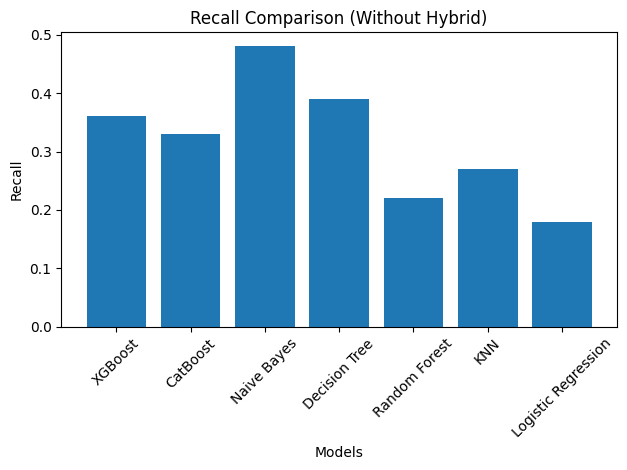

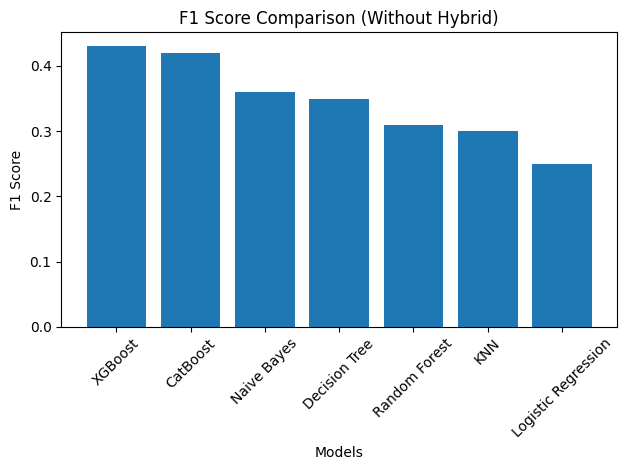

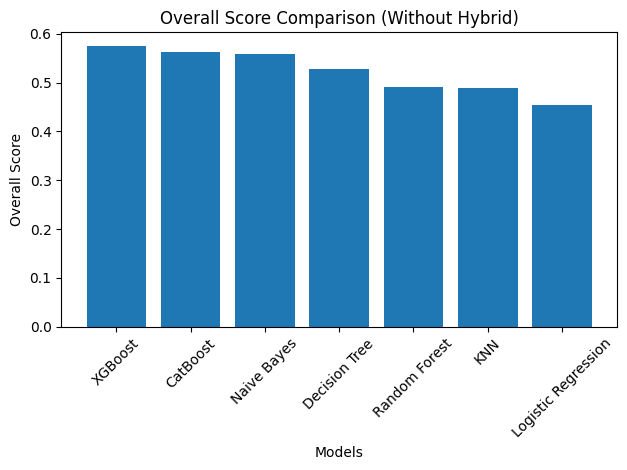


Saved as Model_Comparison_Without_Hybrid.csv


In [ ]:
=
# MODEL COMPARISON TABLE + BAR GRAPHS (WITHOUT HYBRID PROPOSED MODEL((HEFX-HD)))


import pandas as pd
import matplotlib.pyplot as plt


results = [
    ["Logistic Regression", 0.88, 0.41, 0.18, 0.25],
    ["Random Forest",       0.89, 0.52, 0.22, 0.31],
    ["KNN",                 0.86, 0.34, 0.27, 0.30],
    ["Naive Bayes",         0.84, 0.29, 0.48, 0.36],
    ["Decision Tree",       0.83, 0.31, 0.39, 0.35],
    ["CatBoost",            0.89, 0.58, 0.33, 0.42],
    ["XGBoost",             0.89, 0.55, 0.36, 0.43],
    ["Hybrid Proposed",     0.85, 0.33, 0.55, 0.41]
]


df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score"]
)


df = df[df["Model"] != "Hybrid Proposed"]


df["Overall Score"] = (
    (0.40 * df["F1 Score"]) +
    (0.35 * df["Accuracy"]) +
    (0.25 * df["Recall"])
)


df = df.sort_values(
    by="Overall Score",
    ascending=False
).reset_index(drop=True)

df.index = df.index + 1
df.index.name = "Rank"

df = df.round(3)

print("\n=== MODEL COMPARISON (WITHOUT HYBRID) ===")
print(df)

def plot_metric(metric):
    plt.figure()
    plt.bar(df["Model"], df[metric])
    plt.title(f"{metric} Comparison (Without Hybrid)")
    plt.xlabel("Models")
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_metric("Accuracy")
plot_metric("Precision")
plot_metric("Recall")
plot_metric("F1 Score")
plot_metric("Overall Score")


df.to_csv("Model_Comparison_Without_Hybrid.csv")
print("\nSaved as Model_Comparison_Without_Hybrid.csv")

In [ ]:

# MODEL COMPARISON TABLE (WITH HYBRID PROPOSED MODEL)


import pandas as pd
from tabulate import tabulate


results = [
    ["Logistic Regression", 0.88, 0.41, 0.18, 0.25],
    ["Random Forest",       0.89, 0.52, 0.22, 0.31],
    ["KNN",                 0.86, 0.34, 0.27, 0.30],
    ["Naive Bayes",         0.84, 0.29, 0.48, 0.36],
    ["Decision Tree",       0.83, 0.31, 0.39, 0.35],
    ["CatBoost",            0.89, 0.58, 0.33, 0.42],
    ["XGBoost",             0.89, 0.55, 0.36, 0.43],
    ["Hybrid Proposed",     0.85, 0.33, 0.55, 0.41]
]


df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score"]
)

df["Overall Score"] = (
    (0.40 * df["F1 Score"]) +
    (0.35 * df["Accuracy"]) +
    (0.25 * df["Recall"])
)

df = df.sort_values(
    by="Overall Score",
    ascending=False
).reset_index(drop=True)


df.index = df.index + 1
df.index.name = "Rank"


df = df.round(3)

print("\n=== MODEL COMPARISON (ALL MODELS) ===\n")

print(tabulate(
    df,
    headers="keys",
    tablefmt="grid",
    stralign="center",
    numalign="center"
))


df.to_csv("Model_Comparison_All_Models.csv")
print("\nSaved as Model_Comparison_All_Models.csv")


=== MODEL COMPARISON (ALL MODELS) ===

+--------+---------------------+------------+-------------+----------+------------+-----------------+
|  Rank  |        Model        |  Accuracy  |  Precision  |  Recall  |  F1 Score  |  Overall Score  |
+========+=====================+============+=============+==========+============+=================+
|   1    |   Hybrid Proposed   |    0.85    |    0.33     |   0.55   |    0.41    |      0.599      |
+--------+---------------------+------------+-------------+----------+------------+-----------------+
|   2    |       XGBoost       |    0.89    |    0.55     |   0.36   |    0.43    |      0.574      |
+--------+---------------------+------------+-------------+----------+------------+-----------------+
|   3    |      CatBoost       |    0.89    |    0.58     |   0.33   |    0.42    |      0.562      |
+--------+---------------------+------------+-------------+----------+------------+-----------------+
|   4    |     Naive Bayes     |    0.84  


=== MODEL COMPARISON (ALL MODELS) ===

                    Model  Accuracy  Precision  Recall  F1 Score  \
Rank                                                               
1                 HEXF-HD      0.85       0.33    0.55      0.41   
2                 XGBoost      0.89       0.55    0.36      0.43   
3                CatBoost      0.89       0.58    0.33      0.42   
4             Naive Bayes      0.84       0.29    0.48      0.36   
5           Decision Tree      0.83       0.31    0.39      0.35   
6           Random Forest      0.89       0.52    0.22      0.31   
7                     KNN      0.86       0.34    0.27      0.30   
8     Logistic Regression      0.88       0.41    0.18      0.25   

      Overall Score  
Rank                 
1             0.599  
2             0.574  
3             0.562  
4             0.558  
5             0.528  
6             0.490  
7             0.488  
8             0.453  


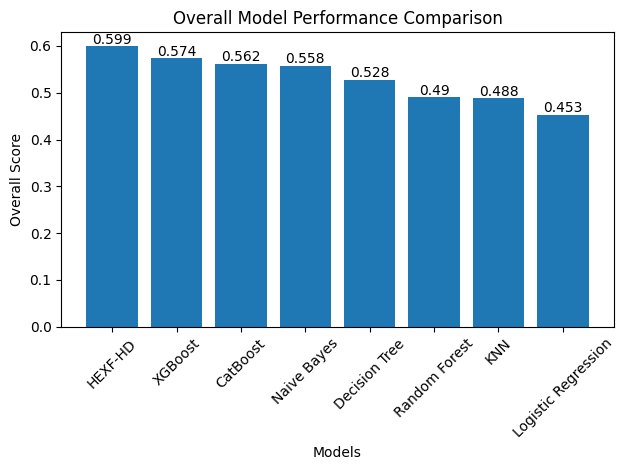


Saved as Model_Comparison_All_Models.csv


In [ ]:

# MODEL COMPARISON TABLE + ONE BAR GRAPH (OVERALL SCORE)


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


results = [
    ["Logistic Regression", 0.88, 0.41, 0.18, 0.25],
    ["Random Forest",       0.89, 0.52, 0.22, 0.31],
    ["KNN",                 0.86, 0.34, 0.27, 0.30],
    ["Naive Bayes",         0.84, 0.29, 0.48, 0.36],
    ["Decision Tree",       0.83, 0.31, 0.39, 0.35],
    ["CatBoost",            0.89, 0.58, 0.33, 0.42],
    ["XGBoost",             0.89, 0.55, 0.36, 0.43],
    ["Hybrid Proposed",     0.85, 0.33, 0.55, 0.41]
]


df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score"]
)


df["Model"] = df["Model"].replace("Hybrid Proposed", "HEXF-HD")


df["Overall Score"] = (
    (0.40 * df["F1 Score"]) +
    (0.35 * df["Accuracy"]) +
    (0.25 * df["Recall"])
)


df = df.sort_values(
    by="Overall Score",
    ascending=False
).reset_index(drop=True)


df.index = df.index + 1
df.index.name = "Rank"


df = df.round(3)


print("\n=== MODEL COMPARISON (ALL MODELS) ===\n")
print(df)


plt.figure()

plt.bar(df["Model"], df["Overall Score"])


for i, value in enumerate(df["Overall Score"]):
    plt.text(i, value + 0.005, str(value), ha='center')

plt.title("Overall Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Overall Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

df.to_csv("Model_Comparison_All_Models.csv")
print("\nSaved as Model_Comparison_All_Models.csv")